# 第 4 章　迴歸分析：線性、多項式與邏輯迴歸

「醫學生的機器學習入門」配套 notebook。對應網站章節：`docs/chapters/04-regression.md`。

- 在 Colab 開啟時請選「執行階段 → 全部執行」。所需套件（numpy、pandas、scikit-learn、statsmodels、matplotlib）Colab 皆已預裝，不需要另外安裝。
- 資料集皆為 scikit-learn 內建（sklearn diabetes、Breast Cancer Wisconsin Diagnostic），**不需網路下載**。
- 圖上標籤用英文，避免 Colab 沒有中文字型而顯示成方塊。
- 本 notebook 的醫學資料僅供學習，不構成臨床建議。

## 0. 環境與版本
先匯入套件並印出版本。本教材以 Colab 現況（scikit-learn 1.6）為底線，也在較新版本測試過。

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

print("Python", sys.version.split()[0])
print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)

Python 3.12.2
numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1


## 1. 載入 sklearn diabetes 資料
442 位糖尿病病人，10 個基線特徵（年齡、性別、BMI、血壓、6 項血清指標），目標 `target` 是一年後的疾病進展指標（連續值，數字愈大代表惡化愈多）。`scaled=False` 保留原始單位，係數才好解讀。

In [2]:
from sklearn.datasets import load_diabetes

df = load_diabetes(as_frame=True, scaled=False).frame
print(df.shape)
df.head()

(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


## 2. 簡單線性迴歸：只用 BMI
先切出訓練集與測試集（75%／25%），只用訓練集找最小平方直線。

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[["bmi"]]
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

lin = LinearRegression().fit(X_train, y_train)
print(f"slope = {lin.coef_[0]:.2f}, intercept = {lin.intercept_:.1f}")

slope = 10.51, intercept = -125.2


斜率約 10.5：在這份資料裡，BMI 每高 1 kg/m²，**模型預測的**一年後進展指標平均高約 10.5。這是關聯，不是因果。

## 3. 用測試集評估：MSE、RMSE、R²

In [4]:
from sklearn.metrics import mean_squared_error, r2_score

pred = lin.predict(X_test)
mse = mean_squared_error(y_test, pred)
print(f"Test MSE = {mse:.0f}, RMSE = {np.sqrt(mse):.1f}, R2 = {r2_score(y_test, pred):.3f}")

Test MSE = 3776, RMSE = 61.4, R2 = 0.317


RMSE 約 61：預測值平均和實際值差 61 個單位左右。R² 約 0.32：BMI 單獨只能解釋測試集約三成的變異。

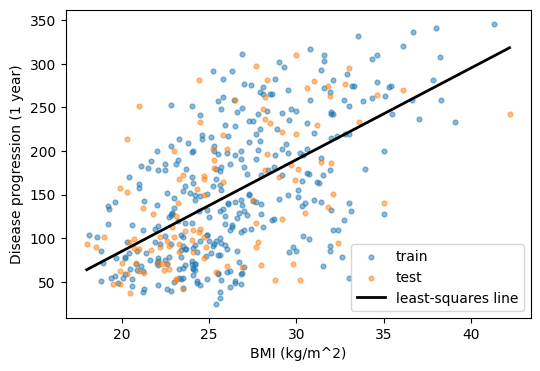

In [5]:
xs = pd.DataFrame({"bmi": np.linspace(X["bmi"].min(), X["bmi"].max(), 100)})
plt.figure(figsize=(6, 4))
plt.scatter(X_train["bmi"], y_train, s=12, alpha=0.5, label="train")
plt.scatter(X_test["bmi"], y_test, s=12, alpha=0.5, label="test")
plt.plot(xs["bmi"], lin.predict(xs), color="black", lw=2, label="least-squares line")
plt.xlabel("BMI (kg/m^2)")
plt.ylabel("Disease progression (1 year)")
plt.legend()
plt.show()

## 4. 多元線性迴歸：放進全部 10 個特徵

In [6]:
X_all = df.drop(columns="target")
Xtr, Xte, ytr, yte = train_test_split(X_all, y, test_size=0.25, random_state=42)

multi = LinearRegression().fit(Xtr, ytr)
pred_m = multi.predict(Xte)
print(f"Train R2 = {r2_score(ytr, multi.predict(Xtr)):.3f}, Test R2 = {r2_score(yte, pred_m):.3f}")
print(f"Test RMSE = {np.sqrt(mean_squared_error(yte, pred_m)):.1f}")
pd.Series(multi.coef_, index=X_all.columns).round(2)

Train R2 = 0.519, Test R2 = 0.485
Test RMSE = 53.4


age     0.17
sex   -23.07
bmi     5.73
bp      1.31
s1     -1.26
s2      0.80
s3      0.43
s4      9.94
s5     63.43
s6      0.11
dtype: float64

測試集 R² 從 0.32 升到約 0.48。注意每個係數的單位不同（`s5` 是 log 轉換後的三酸甘油酯，範圍只有 3–6，所以係數看起來很大），**係數大小不能直接比較重要性**。

## 5. 自己寫梯度下降
把 BMI 標準化後，從斜率 0、截距 0 出發，每一步沿著 MSE 下降最快的方向走一小步。

In [7]:
x = X_train["bmi"].to_numpy()
x_std = (x - x.mean()) / x.std()
yv = y_train.to_numpy()

w, b = 0.0, 0.0
learning_rate = 0.1
losses = []
for step in range(200):
    error = (w * x_std + b) - yv
    losses.append(np.mean(error ** 2))
    w -= learning_rate * 2 * np.mean(error * x_std)   # d(MSE)/dw
    b -= learning_rate * 2 * np.mean(error)           # d(MSE)/db

print(f"gradient descent slope (original BMI units) = {w / x.std():.2f}")
print(f"LinearRegression slope                       = {lin.coef_[0]:.2f}")

gradient descent slope (original BMI units) = 10.51
LinearRegression slope                       = 10.51


兩個斜率一樣：梯度下降一步一步走到的，就是最小平方公式直接算出的答案。下圖是每一步的 MSE。

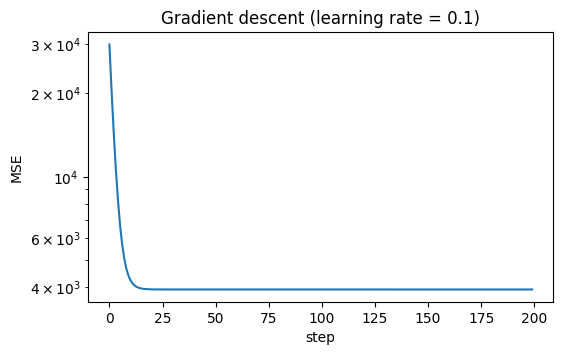

In [8]:
plt.figure(figsize=(6, 3.5))
plt.plot(losses)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("MSE")
plt.title("Gradient descent (learning rate = 0.1)")
plt.show()

## 6. 預測 vs 解釋：statsmodels 的 OLS
同樣是線性迴歸，statsmodels 會給係數的 95% 信賴區間與 p 值，這是統計推論（解釋）的工具。這裡用全部 442 人。

In [9]:
import statsmodels.api as sm

ols = sm.OLS(y, sm.add_constant(X_all)).fit()
ci = ols.conf_int()
table = pd.DataFrame({"coef": ols.params, "CI_low": ci[0], "CI_high": ci[1], "p": ols.pvalues})
print(f"R2 = {ols.rsquared:.3f}")
table.round(3)

R2 = 0.518


,coef,CI_low,CI_high,p
const,-334.567,-467.148,-201.986,0.000
age,-0.036,-0.463,0.390,0.867
sex,-22.860,-34.330,-11.389,0.000
bmi,5.603,4.194,7.012,0.000
bp,1.117,0.674,1.560,0.000
s1,-1.090,-2.217,0.037,0.058
s2,0.746,-0.297,1.790,0.160
s3,0.372,-1.166,1.910,0.635
s4,6.534,-5.178,18.245,0.273
s5,68.483,37.685,99.282,0.000


`age` 的 p 值約 0.87：校正其他變數後，年齡與進展指標的關聯**未達統計顯著**（不等於「年齡沒有影響」）。

## 7. 多項式迴歸與過擬合
用模擬的劑量反應資料（真實曲線會飽和），比較 1、3、15 次方多項式。先把劑量縮放到 [-1, 1]，高次方才不會數值爆掉。

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

def true_curve(dose):
    return 100 * dose / (2 + dose)

rng = np.random.default_rng(42)
x_tr = np.sort(rng.uniform(0, 10, 25))
y_tr = true_curve(x_tr) + rng.normal(0, 8, 25)
x_te = rng.uniform(x_tr.min(), x_tr.max(), 200)
y_te = true_curve(x_te) + rng.normal(0, 8, 200)

models = {}
for degree in [1, 3, 15]:
    model = make_pipeline(MinMaxScaler(feature_range=(-1, 1)),
                          PolynomialFeatures(degree),
                          LinearRegression())
    model.fit(x_tr.reshape(-1, 1), y_tr)
    models[degree] = model
    train_mse = mean_squared_error(y_tr, model.predict(x_tr.reshape(-1, 1)))
    test_mse = mean_squared_error(y_te, model.predict(x_te.reshape(-1, 1)))
    print(f"degree {degree:2d}: train MSE = {train_mse:7.1f}, test MSE = {test_mse:7.1f}")

degree  1: train MSE =    68.4, test MSE =    94.4
degree  3: train MSE =    30.3, test MSE =    69.4
degree 15: train MSE =     7.0, test MSE =  1472.8


15 次方的訓練誤差最小，測試誤差卻暴增：它背下了訓練集的雜訊。

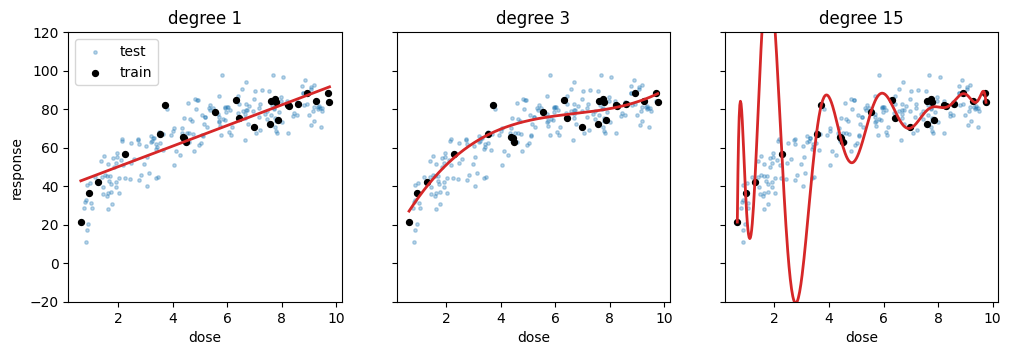

In [11]:
grid = np.linspace(x_tr.min(), x_tr.max(), 400).reshape(-1, 1)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, degree in zip(axes, [1, 3, 15]):
    ax.scatter(x_te, y_te, s=6, alpha=0.3, label="test")
    ax.scatter(x_tr, y_tr, s=18, color="black", label="train")
    ax.plot(grid, models[degree].predict(grid), color="tab:red", lw=2)
    ax.set_ylim(-20, 120)
    ax.set_title(f"degree {degree}")
    ax.set_xlabel("dose")
axes[0].set_ylabel("response")
axes[0].legend()
plt.show()

## 8. 正則化：替 15 次方踩剎車
Ridge 迴歸在 MSE 之外加上「係數平方和」的懲罰，讓係數不能亂長。

In [12]:
from sklearn.linear_model import Ridge

for alpha in [0.001, 0.01, 0.1]:
    ridge = make_pipeline(MinMaxScaler(feature_range=(-1, 1)),
                          PolynomialFeatures(15),
                          Ridge(alpha=alpha))
    ridge.fit(x_tr.reshape(-1, 1), y_tr)
    test_mse = mean_squared_error(y_te, ridge.predict(x_te.reshape(-1, 1)))
    print(f"Ridge alpha = {alpha:<5}: test MSE = {test_mse:.1f}")

Ridge alpha = 0.001: test MSE = 80.4
Ridge alpha = 0.01 : test MSE = 79.9
Ridge alpha = 0.1  : test MSE = 80.9


## 9. 邏輯迴歸：WDBC 乳癌良惡性
sklearn 的編碼是 0 = 惡性、1 = 良性，和醫學習慣相反；這裡翻轉成 **1 = 惡性**，讓「陽性」代表惡性。邏輯迴歸前一律先標準化（放進 Pipeline）。

In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

bc = load_breast_cancer(as_frame=True)
Xb = bc.data
yb = 1 - bc.target   # 1 = malignant, 0 = benign

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    Xb, yb, test_size=0.25, stratify=yb, random_state=42)

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
clf.fit(Xb_tr, yb_tr)
proba = clf.predict_proba(Xb_te)[:, 1]   # predicted probability of malignancy
print("first 5 probabilities:", proba[:5].round(3))

first 5 probabilities: [0.999 0.004 1.    0.    0.035]


## 10. 閾值與混淆矩陣
同一組機率，切在不同閾值，敏感度與特異度就會此消彼長。

In [14]:
from sklearn.metrics import confusion_matrix

for threshold in [0.5, 0.2]:
    pred_label = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(yb_te, pred_label).ravel()
    print(f"threshold {threshold}: TP={tp} FN={fn} FP={fp} TN={tn} | "
          f"sensitivity={tp / (tp + fn):.3f}, specificity={tn / (tn + fp):.3f}")

threshold 0.5: TP=49 FN=4 FP=1 TN=89 | sensitivity=0.925, specificity=0.989
threshold 0.2: TP=51 FN=2 FP=3 TN=87 | sensitivity=0.962, specificity=0.967


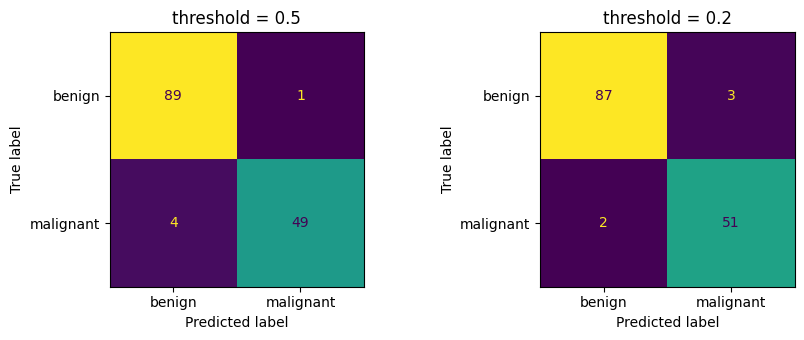

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, threshold in zip(axes, [0.5, 0.2]):
    ConfusionMatrixDisplay.from_predictions(
        yb_te, (proba >= threshold).astype(int),
        display_labels=["benign", "malignant"], ax=ax, colorbar=False)
    ax.set_title(f"threshold = {threshold}")
plt.tight_layout()
plt.show()

## 11. 係數 → 勝算比（odds ratio）
只用 3 個特徵建一個小模型，把係數取指數得到「每增加 1 個標準差，惡性勝算乘上幾倍」。再用 statsmodels 的不懲罰版本對照。

In [16]:
features = ["worst radius", "worst texture", "worst concave points"]
small = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
small.fit(Xb_tr[features], yb_tr)
coef = small[-1].coef_[0]
pd.DataFrame({"coef (per SD)": coef, "odds ratio (per SD)": np.exp(coef)}, index=features).round(2)

,coef (per SD),odds ratio (per SD)
worst radius,3.33,27.92
worst texture,1.31,3.69
worst concave points,2.25,9.48


In [17]:
Xs = pd.DataFrame(StandardScaler().fit_transform(Xb_tr[features]),
                  columns=features, index=Xb_tr.index)
logit = sm.Logit(yb_tr, sm.add_constant(Xs)).fit(disp=0)
or_table = pd.DataFrame({"OR": np.exp(logit.params),
                         "CI_low": np.exp(logit.conf_int()[0]),
                         "CI_high": np.exp(logit.conf_int()[1])})
or_table.round(2)

,OR,CI_low,CI_high
const,0.31,0.17,0.58
worst radius,160.50,28.81,894.24
worst texture,5.89,2.81,12.31
worst concave points,18.25,5.80,57.37


兩個版本的勝算比差很多：sklearn 預設有 L2 正則化，會把係數往 0 拉；statsmodels 沒有懲罰，但信賴區間非常寬（三個特徵彼此高度相關）。**要做統計推論請用 statsmodels 這類工具，並好好處理共線性；sklearn 的係數是為了預測而調過的。**

## 動手試試

1. 第 7 節把訓練點數 `25` 改成 `100`（兩處），15 次方的測試誤差會怎麼變？為什麼資料變多能減輕過擬合？
2. 第 5 節把 `learning_rate` 改成 `0.01` 和 `1.02`，看 loss 曲線怎麼變化。
3. 第 10 節把閾值改成 `0.8`，記下敏感度與特異度；如果這是篩檢工具，你會選哪個閾值？